# TCN-Attention-LSTM 模型训练与预测（重构版）

## 两种运行模式
- **模式 A（默认）**：使用已知最优参数直接训练 → 快（CPU 约 5-10 分钟）
- **模式 B（可选）**：快速贝叶斯搜索 + 训练 → 需要搜索新参数时启用（约 20-30 分钟）

## 已知最优参数（来自之前的搜索）
- `hidden_size`: 69
- `lr`: 0.0006238221652559504
- `batch_size`: 128

**流程**：
1. 导入库 & 数据加载
2. 数据归一化 & 构造时间序列
3. 定义模型结构
4. （可选）快速贝叶斯优化
5. 用最优参数训练模型
6. MC Dropout 预测 & 评估
7. 结果可视化

## ⚙️ 运行配置（在这里切换模式）

In [2]:
# ========== 运行模式配置 ==========
ENABLE_OPTUNA_SEARCH = True   # True=贝叶斯搜索, False=直接用已知最优参数

# ========== 已知最优超参数（模式 A 使用）==========
BEST_HIDDEN_SIZE = 69
BEST_LR = 0.0006238221652559504
BEST_BATCH_SIZE = 128

# ========== 训练配置 ==========
FINAL_EPOCHS = 200
PATIENCE = 15
MC_TIMES = 100          # MC Dropout 采样次数

# ========== Optuna 贝叶斯搜索配置（模式 B 使用）==========
OPTUNA_N_TRIALS = 10    # 搜索次数（原来 25 太大）
OPTUNA_EPOCHS = 30      # 每个 trial 最大训练轮数（原来 100 太大）
OPTUNA_PATIENCE = 5     # 早停耐心值
OPTUNA_TIMEOUT = 1800   # 搜索超时限制（秒），30分钟

print(f"运行模式: {'贝叶斯搜索' if ENABLE_OPTUNA_SEARCH else '直接使用已知最优参数'}")
print(f"最终训练轮数: {FINAL_EPOCHS}")

运行模式: 贝叶斯搜索
最终训练轮数: 200


## 1. 导入库 & 加载数据

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

if ENABLE_OPTUNA_SEARCH:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"设备: {DEVICE}")
print(f"PyTorch 版本: {torch.__version__}")

设备: cuda
PyTorch 版本: 2.1.0+cu121


In [4]:
# ============================================
# 2. 加载数据 & 归一化
# ============================================
train = pd.read_csv("dataset_selected_features_train.csv")
test = pd.read_csv("dataset_selected_features_test.csv")

timestamp_test = pd.to_datetime(test["timestamp"])
train = train.drop(columns=["timestamp"])
test = test.drop(columns=["timestamp"])
train = train.dropna()
test = test.dropna()

X_train = train.drop(columns=["load_kw"])
y_train = train["load_kw"]
X_test = test.drop(columns=["load_kw"])
y_test = test["load_kw"]

print(f"训练集: X{X_train.shape}, y{y_train.shape}")
print(f"测试集: X{X_test.shape}, y{y_test.shape}")
print(f"特征列: {list(X_train.columns)}")

# 归一化
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# 保存 scaler（供后续使用）
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)
with open("scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

print("数据归一化完成，scaler 已保存。")

训练集: X(4225, 6), y(4225,)
测试集: X(1057, 6), y(1057,)
特征列: ['price', 'lag_1', 'lag_96', 'lag_672', 'rolling_std_4', 'rolling_mean_4']
数据归一化完成，scaler 已保存。


## 3. 构造时间序列 & Tensor

In [5]:
TIME_STEPS = 96

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

Xs_train, ys_train = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
Xs_test, ys_test = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"训练序列形状: {Xs_train.shape}")
print(f"测试序列形状: {Xs_test.shape}")

Xs_train_tensor = torch.tensor(Xs_train, dtype=torch.float32)
ys_train_tensor = torch.tensor(ys_train, dtype=torch.float32)
Xs_test_tensor = torch.tensor(Xs_test, dtype=torch.float32)
ys_test_tensor = torch.tensor(ys_test, dtype=torch.float32)

INPUT_DIM = Xs_train_tensor.shape[2]
print(f"输入特征维度: {INPUT_DIM}")

# 创建完整数据集
train_dataset = TensorDataset(Xs_train_tensor, ys_train_tensor)
test_dataset = TensorDataset(Xs_test_tensor, ys_test_tensor)

训练序列形状: (4129, 96, 6)
测试序列形状: (961, 96, 6)
输入特征维度: 6


## 4. 定义模型结构

In [6]:
class TCNBlock(nn.Module):
    """TCN 块：因果卷积 + ReLU + Dropout + 残差连接"""
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super(TCNBlock, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.residual = (nn.Conv1d(in_channels, out_channels, 1)
                         if in_channels != out_channels else nn.Identity())

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :-(self.conv.padding[0])]
        out = self.relu(out)
        out = self.dropout(out)
        return out + self.residual(x)


class SimpleAttention(nn.Module):
    """简单注意力机制"""
    def __init__(self, hidden_dim):
        super(SimpleAttention, self).__init__()
        self.attn_weights = nn.Parameter(torch.randn(hidden_dim, 1))

    def forward(self, x):
        scores = torch.matmul(x, self.attn_weights).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return x * weights


class HybridModel(nn.Module):
    """TCN + Attention + LSTM 混合模型"""
    def __init__(self, input_size, hidden_size, output_size):
        super(HybridModel, self).__init__()
        tcn_layers = []
        channels = [input_size, 64, 64, 64, 64, 64]
        dilations = [1, 2, 4, 8, 16]
        for i in range(len(dilations)):
            tcn_layers.append(
                TCNBlock(channels[i], channels[i+1], kernel_size=3, dilation=dilations[i])
            )
        self.tcn = nn.Sequential(*tcn_layers)
        self.attention = SimpleAttention(64)
        self.lstm = nn.LSTM(64, hidden_size, batch_first=True, num_layers=1, dropout=0.1)
        self.fc = nn.Linear(hidden_size + input_size, output_size)

    def forward(self, x):
        raw_last_step = x[:, -1, :]
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x.transpose(1, 2)
        x = self.attention(x)
        _, (hn, _) = self.lstm(x)
        lstm_out = hn[-1]
        combined = torch.cat([lstm_out, raw_last_step], dim=1)
        return torch.relu(self.fc(combined))


class EarlyStopping:
    """早停机制"""
    def __init__(self, patience=10, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

print("模型结构定义完成。")
# 统计参数量
dummy_model = HybridModel(INPUT_DIM, BEST_HIDDEN_SIZE, 1)
total_params = sum(p.numel() for p in dummy_model.parameters())
trainable_params = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")
del dummy_model

模型结构定义完成。
总参数量: 88,472
可训练参数量: 88,472


c:\Users\杉嶋桐惠\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


## 5. 定义训练函数

In [7]:
def train_model(model, train_loader, val_loader, epochs, lr,
                patience=10, save_path='best_pth/model.pth',
                verbose=True, scheduler_factor=0.5, scheduler_patience=5):
    """
    训练模型，支持早停和学习率调度。
    返回 (train_loss_history, val_loss_history)
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor,
        patience=scheduler_patience, verbose=verbose
    )
    early_stopping = EarlyStopping(patience=patience, verbose=verbose, path=save_path)

    train_losses = []
    val_losses = []
    total_start = time.time()

    for epoch in range(epochs):
        # --- 训练阶段 ---
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # --- 验证阶段 ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
                outputs = model(batch_X)
                total_val_loss += criterion(outputs, batch_y).item()
        avg_val_loss = total_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # 学习率调度
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # 进度打印
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            elapsed = time.time() - total_start
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | "
                  f"LR: {current_lr:.2e} | Time: {elapsed:.0f}s")

        # 早停检查
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            if verbose:
                print(f"早停触发于 Epoch {epoch+1}")
            break

    # 加载最佳模型
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    total_time = time.time() - total_start
    if verbose:
        print(f"训练完成，总耗时: {total_time:.1f}s，最佳验证损失: {early_stopping.val_loss_min:.6f}")

    return train_losses, val_losses

print("训练函数定义完成。")

训练函数定义完成。


## 6A.（可选）快速贝叶斯优化搜索最优超参数

> 仅当 `ENABLE_OPTUNA_SEARCH = True` 时运行。使用训练集内部划分验证集（不用测试集避免数据泄露），添加 MedianPruner 剪枝器加速搜索。

In [8]:
best_params = {
    "hidden_size": BEST_HIDDEN_SIZE,
    "lr": BEST_LR,
    "batch_size": BEST_BATCH_SIZE
}

if ENABLE_OPTUNA_SEARCH:
    print("=" * 50)
    print("开始快速贝叶斯优化搜索...")
    print(f"  n_trials={OPTUNA_N_TRIALS}, epochs/trial={OPTUNA_EPOCHS}")
    print(f"  patience={OPTUNA_PATIENCE}, timeout={OPTUNA_TIMEOUT}s")
    print("=" * 50)

    # 从训练集中划分验证集（不用测试集）
    opt_train_size = int(0.8 * len(train_dataset))
    opt_val_size = len(train_dataset) - opt_train_size
    opt_train_data, opt_val_data = torch.utils.data.random_split(
        train_dataset, [opt_train_size, opt_val_size]
    )
    print(f"搜索用训练集: {len(opt_train_data)}, 搜索用验证集: {len(opt_val_data)}")

    # 用于剪枝的最小样本数
    STUDY_DIR = "best_pth"
    os.makedirs(STUDY_DIR, exist_ok=True)

    def objective(trial):
        trial_start = time.time()

        hidden_size = trial.suggest_int("hidden_size", 32, 128)
        # 收紧 learning rate 范围，避免取到 >1 的离谱值
        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        train_loader = DataLoader(opt_train_data, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(opt_val_data, batch_size=batch_size, shuffle=False)

        model = HybridModel(INPUT_DIM, hidden_size, 1).to(DEVICE)

        # 使用更小的 patience 和 verbose=False 减少输出
        _, val_history = train_model(
            model, train_loader, val_loader,
            epochs=OPTUNA_EPOCHS, lr=lr,
            patience=OPTUNA_PATIENCE,
            save_path=f"{STUDY_DIR}/_temp_trial_{trial.number}.pth",
            verbose=False
        )

        best_val = min(val_history)
        elapsed = time.time() - trial_start

        # 报告中间值用于剪枝（每10个epoch报告一次）
        for epoch_idx, val_loss in enumerate(val_history):
            trial.report(val_loss, epoch_idx)
            if trial.should_prune():
                print(f"  Trial {trial.number}: 在第{epoch_idx}个epoch被剪枝，"
                      f"best_val={best_val:.6f}, 用时{elapsed:.0f}s")
                raise optuna.exceptions.TrialPruned()

        print(f"  Trial {trial.number}: hidden={hidden_size}, lr={lr:.2e}, "
              f"batch={batch_size}, best_val={best_val:.6f}, 用时{elapsed:.0f}s")
        return best_val

    # 创建 study：TPE 采样器 + Median 剪枝器
    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=5, interval_steps=10)
    )

    try:
        study.optimize(
            objective,
            n_trials=OPTUNA_N_TRIALS,
            timeout=OPTUNA_TIMEOUT,
            show_progress_bar=True
        )
    except KeyboardInterrupt:
        print("\n搜索被用户中断，使用当前最佳结果。")

    # 更新最优参数
    best_params = study.best_params
    print(f"\n最优参数: {best_params}")
    print(f"最优值 (val_loss): {study.best_value:.6f}")
else:
    print(f"跳过贝叶斯搜索，使用已知最优参数: {best_params}")

[I 2026-05-23 00:17:20,989] A new study created in memory with name: no-name-8b2cbc14-6d25-4ef8-a92e-b1f0f2cf4255


开始快速贝叶斯优化搜索...
  n_trials=10, epochs/trial=30
  patience=5, timeout=1800s
搜索用训练集: 3303, 搜索用验证集: 826


  0%|          | 0/10 [00:00<?, ?it/s]

  Trial 0: hidden=68, lr=4.12e-03, batch=32, best_val=0.015041, 用时52s
[I 2026-05-23 00:18:12,570] Trial 0 finished with value: 0.015040569508878084 and parameters: {'hidden_size': 68, 'lr': 0.004123206532618728, 'batch_size': 32}. Best is trial 0 with value: 0.015040569508878084.


c:\Users\杉嶋桐惠\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


  Trial 1: hidden=47, lr=1.26e-04, batch=32, best_val=0.006792, 用时85s
[I 2026-05-23 00:19:37,618] Trial 1 finished with value: 0.0067920669501360794 and parameters: {'hidden_size': 47, 'lr': 0.00012551115172973836, 'batch_size': 32}. Best is trial 1 with value: 0.0067920669501360794.
  Trial 2: 在第5个epoch被剪枝，best_val=0.015046, 用时38s
[I 2026-05-23 00:20:15,598] Trial 2 pruned. 
  Trial 3: 在第5个epoch被剪枝，best_val=0.006150, 用时79s
[I 2026-05-23 00:21:34,845] Trial 3 pruned. 
  Trial 4: 在第5个epoch被剪枝，best_val=0.015151, 用时45s
[I 2026-05-23 00:22:20,240] Trial 4 pruned. 
  Trial 5: 在第5个epoch被剪枝，best_val=0.004670, 用时90s
[I 2026-05-23 00:23:50,317] Trial 5 pruned. 
  Trial 6: 在第5个epoch被剪枝，best_val=0.013775, 用时50s
[I 2026-05-23 00:24:40,474] Trial 6 pruned. 
  Trial 7: 在第5个epoch被剪枝，best_val=0.005422, 用时88s
[I 2026-05-23 00:26:08,858] Trial 7 pruned. 
  Trial 8: hidden=43, lr=6.94e-04, batch=64, best_val=0.004591, 用时72s
[I 2026-05-23 00:27:20,661] Trial 8 finished with value: 0.004591252708521027 and

## 6B. 用最优参数训练最终模型

In [9]:
print("=" * 50)
print(f"使用参数训练最终模型: {best_params}")
print(f"训练轮数: {FINAL_EPOCHS}, 耐心值: {PATIENCE}")
print("=" * 50)

# 从训练集划分 90%/10% 用于早停
full_train_size = int(0.9 * len(train_dataset))
final_val_size = len(train_dataset) - full_train_size
f_t_data, f_v_data = torch.utils.data.random_split(
    train_dataset, [full_train_size, final_val_size]
)

final_train_loader = DataLoader(f_t_data, batch_size=best_params["batch_size"], shuffle=True)
final_val_loader = DataLoader(f_v_data, batch_size=best_params["batch_size"], shuffle=False)

print(f"最终训练集: {len(f_t_data)}, 最终验证集: {len(f_v_data)}")

# 实例化模型
model = HybridModel(
    input_size=INPUT_DIM,
    hidden_size=best_params["hidden_size"],
    output_size=1
).to(DEVICE)

os.makedirs("best_pth", exist_ok=True)

train_losses, val_losses = train_model(
    model,
    final_train_loader,
    final_val_loader,
    epochs=FINAL_EPOCHS,
    lr=best_params["lr"],
    patience=PATIENCE,
    save_path="best_pth/final_best_hybrid_model.pth",
    verbose=True
)

# 保存训练历史
with open("final_train_history.pkl", "wb") as f:
    pickle.dump({"train_losses": train_losses, "val_losses": val_losses}, f)
print("训练历史已保存到 final_train_history.pkl")

# 也保存一个带时间戳的副本
torch.save(model.state_dict(), "best_pth/model_final.pth")

使用参数训练最终模型: {'hidden_size': 43, 'lr': 0.00069389014127394, 'batch_size': 64}
训练轮数: 200, 耐心值: 15
最终训练集: 3716, 最终验证集: 413
Epoch   1/200 | Train Loss: 0.031932 | Val Loss: 0.023209 | LR: 6.94e-04 | Time: 3s
Epoch   6/200 | Train Loss: 0.012458 | Val Loss: 0.014661 | LR: 6.94e-04 | Time: 16s
EarlyStopping counter: 1 out of 15
Epoch  11/200 | Train Loss: 0.011585 | Val Loss: 0.014280 | LR: 6.94e-04 | Time: 29s
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 1 out of 15
Epoch  16/200 | Train Loss: 0.011427 | Val Loss: 0.013823 | LR: 6.94e-04 | Time: 41s
Epoch  21/200 | Train Loss: 0.011222 | Val Loss: 0.012964 | LR: 6.94e-04 | Time: 51s
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 2 out of 15
Epoch  26/200 | Train Loss: 0.010516 | Val Loss: 0.012662 | LR: 6.94e-04 | Time: 58s
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 2 out of 15
EarlyStopping counter: 1 out of 15
Epoch  31/200 | Train Loss: 0.010484 | Val Loss: 0.01287

## 7. 绘制损失曲线

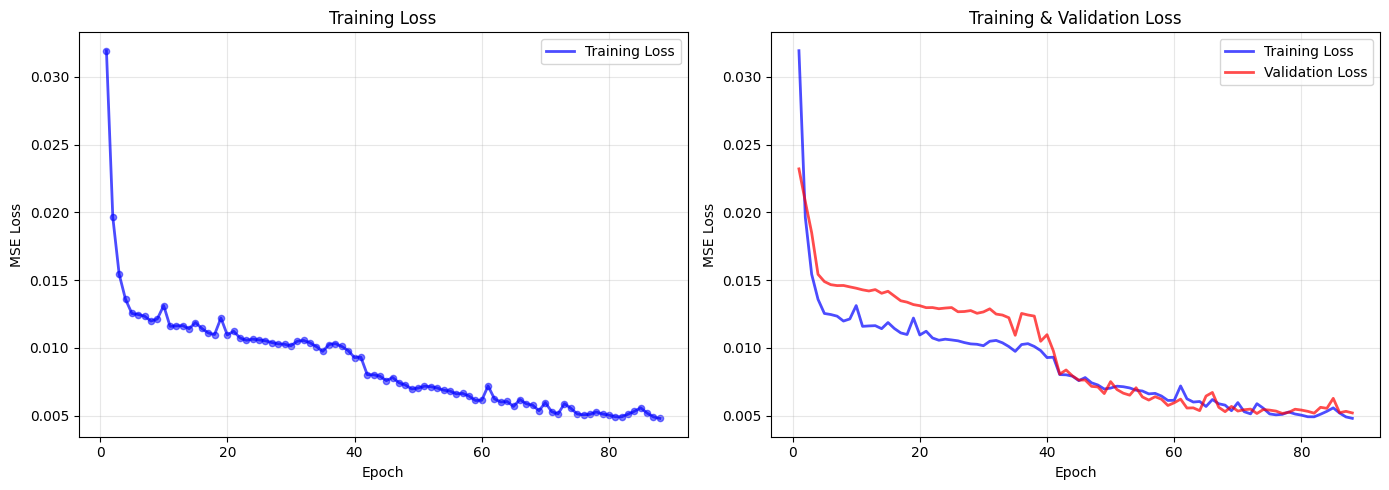

最终训练损失: 0.004793
最终验证损失: 0.005192
最佳验证损失: 0.005150 (Epoch 73)


In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
plt.scatter(epochs_range, train_losses, color='blue', s=20, alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-', linewidth=2, alpha=0.7, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最终训练损失: {train_losses[-1]:.6f}")
print(f"最终验证损失: {val_losses[-1]:.6f}")
print(f"最佳验证损失: {min(val_losses):.6f} (Epoch {val_losses.index(min(val_losses)) + 1})")

## 8. 训练集拟合能力评估

训练集评价结果:
  MAE  : 168.11 kW
  RMSE : 223.26 kW
  MAPE : 94.39%
  R²   : 0.9079


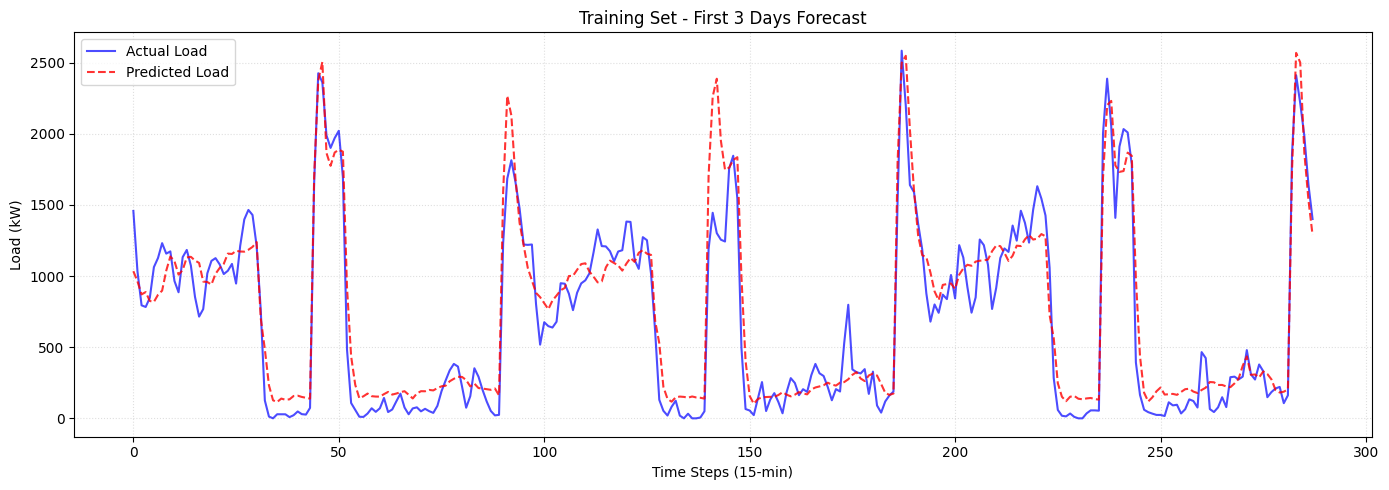

In [11]:
model.eval()

with torch.no_grad():
    train_pred = model(Xs_train_tensor.to(DEVICE)).cpu().numpy()

# 逆归一化
y_train_real = scaler_y.inverse_transform(ys_train_tensor.cpu().numpy().reshape(-1, 1))
y_train_pred = scaler_y.inverse_transform(train_pred.reshape(-1, 1))

train_mae = mean_absolute_error(y_train_real, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
mask = y_train_real > 1
train_mape = np.mean(np.abs((y_train_real[mask] - y_train_pred[mask]) / y_train_real[mask]))
train_r2 = r2_score(y_train_real, y_train_pred)

print("训练集评价结果:")
print(f"  MAE  : {train_mae:.2f} kW")
print(f"  RMSE : {train_rmse:.2f} kW")
print(f"  MAPE : {train_mape:.2%}")
print(f"  R²   : {train_r2:.4f}")

# 可视化前3天
plt.figure(figsize=(14, 5))
show_len = 96 * 3
plt.plot(y_train_real[:show_len], label='Actual Load', color='blue', alpha=0.7)
plt.plot(y_train_pred[:show_len], label='Predicted Load', color='red', linestyle='--', alpha=0.8)
plt.title('Training Set - First 3 Days Forecast')
plt.xlabel('Time Steps (15-min)')
plt.ylabel('Load (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. MC Dropout 预测（测试集）

In [12]:
print(f"正在执行蒙特卡洛采样预测 (MC_TIMES={MC_TIMES})...")

def predict_with_uncertainty(model, X_tensor, mc_times=MC_TIMES):
    """MC Dropout 预测，返回均值和标准差"""
    model.train()  # 保持 Dropout 开启
    predictions = []
    with torch.no_grad():
        for _ in range(mc_times):
            y_p = model(X_tensor)
            predictions.append(y_p.cpu().numpy())
    predictions = np.array(predictions)
    y_mean = predictions.mean(axis=0)
    y_std = predictions.std(axis=0)
    return y_mean, y_std

y_pred_scaled, y_std_scaled = predict_with_uncertainty(
    model, Xs_test_tensor.to(DEVICE), MC_TIMES
)
print("MC 预测完成。")

正在执行蒙特卡洛采样预测 (MC_TIMES=100)...
MC 预测完成。


## 10. 逆归一化 & 测试集评估

In [13]:
# 逆归一化
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(ys_test.reshape(-1, 1))

# 标准差逆归一化（只需乘以缩放系数）
scale_factor = scaler_y.data_max_[0] - scaler_y.data_min_[0]
y_std_real = y_std_scaled * scale_factor

# 评估指标
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-5)))
r2 = r2_score(y_test_real, y_pred_real)

print("=" * 40)
print("测试集预测评价结果:")
print(f"  MAE  : {mae:.2f} kW")
print(f"  RMSE : {rmse:.2f} kW")
print(f"  MAPE : {mape:.2%}")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

测试集预测评价结果:
  MAE  : 209.88 kW
  RMSE : 304.06 kW
  MAPE : 22848820.34%
  R²   : 0.8598


## 11. 结果可视化

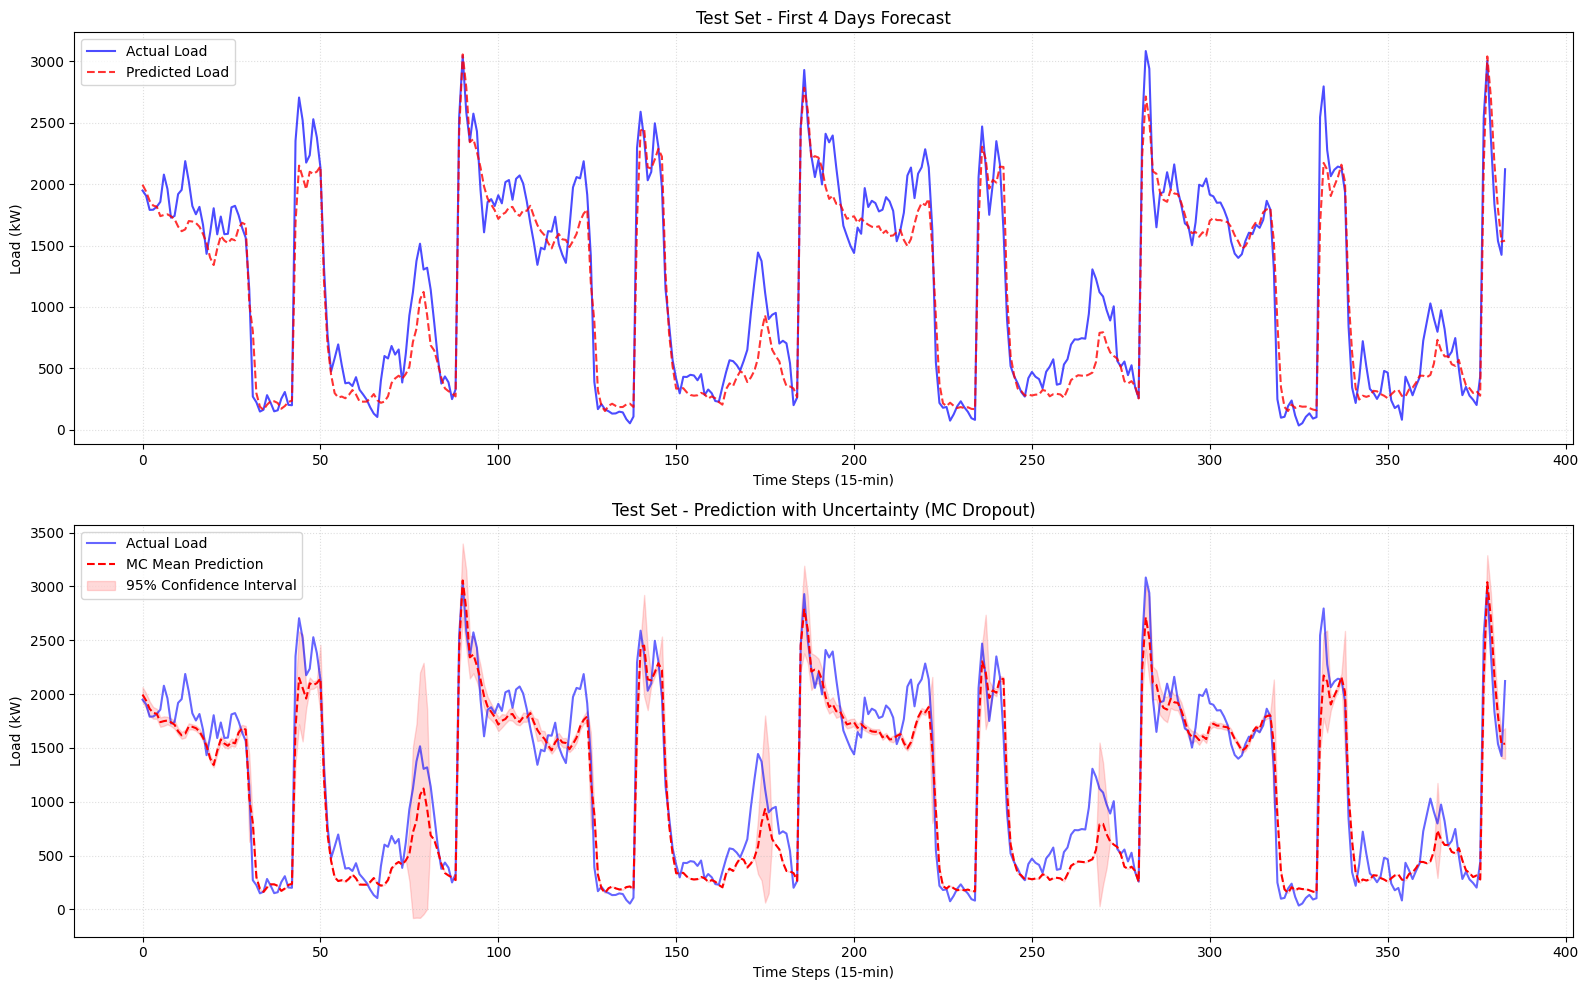

In [14]:
# --- 整体对比图 ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 图1：前 4 天（96*4=384 步）
show_len = 384
axes[0].plot(y_test_real[:show_len], label='Actual Load', color='blue', alpha=0.7)
axes[0].plot(y_pred_real[:show_len], label='Predicted Load', color='red', linestyle='--', alpha=0.8)
axes[0].set_title('Test Set - First 4 Days Forecast')
axes[0].set_xlabel('Time Steps (15-min)')
axes[0].set_ylabel('Load (kW)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.4)

# 图2：带置信区间的 MC Dropout
show_len = 384
time_axis = range(show_len)
lower_bound = (y_pred_real - 1.96 * y_std_real).flatten()[:show_len]
upper_bound = (y_pred_real + 1.96 * y_std_real).flatten()[:show_len]

axes[1].plot(time_axis, y_test_real[:show_len], label='Actual Load', color='blue', alpha=0.6)
axes[1].plot(time_axis, y_pred_real[:show_len], label='MC Mean Prediction', color='red', linestyle='--')
axes[1].fill_between(time_axis, lower_bound, upper_bound, color='red', alpha=0.15,
                     label='95% Confidence Interval')
axes[1].set_title('Test Set - Prediction with Uncertainty (MC Dropout)')
axes[1].set_xlabel('Time Steps (15-min)')
axes[1].set_ylabel('Load (kW)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

展示日期: 2026-01-25 (第 3 天)


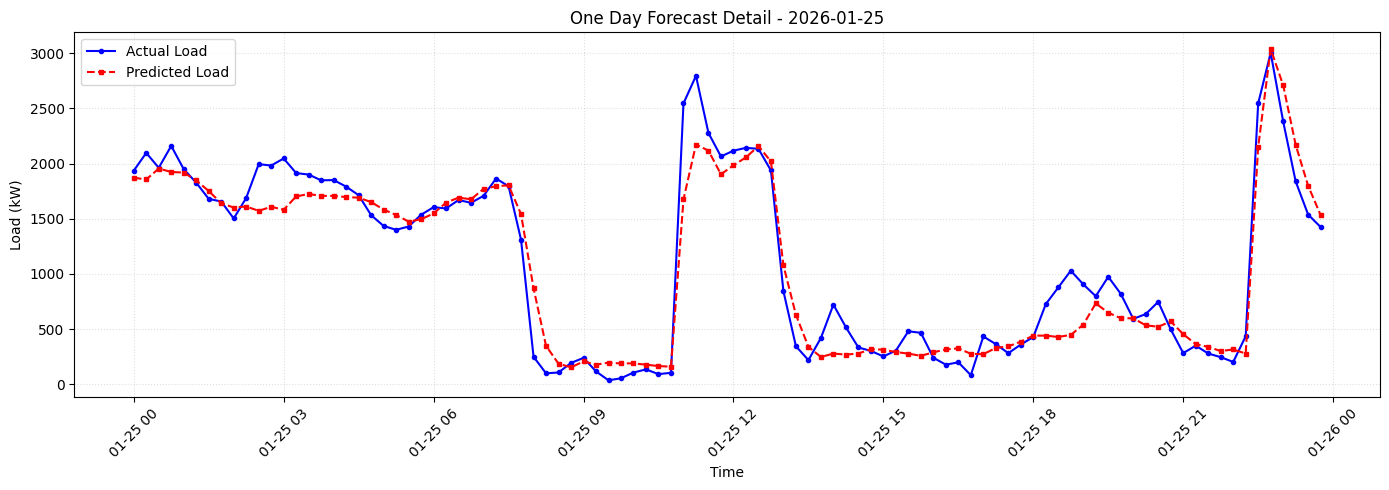

In [15]:
# --- 某一天预测效果 ---
ONEDAY = 3  # 可选 0~9，选择测试集中某一天

time_test = timestamp_test.iloc[-len(y_test_real):]
result = pd.DataFrame({
    "time": time_test.values,
    "real": y_test_real.flatten(),
    "pred": y_pred_real.flatten()
})
result["date"] = pd.to_datetime(result["time"]).dt.date

unique_dates = result["date"].unique()
if ONEDAY < len(unique_dates):
    one_day = unique_dates[ONEDAY]
else:
    one_day = unique_dates[-1]
    ONEDAY = len(unique_dates) - 1

print(f"展示日期: {one_day} (第 {ONEDAY} 天)")
day_data = result[result["date"] == one_day]

plt.figure(figsize=(14, 5))
plt.plot(day_data["time"], day_data["real"], label="Actual Load", color='blue', marker='o', markersize=3)
plt.plot(day_data["time"], day_data["pred"], label="Predicted Load", color='red', linestyle='--', marker='s', markersize=3)
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.title(f"One Day Forecast Detail - {one_day}")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. 保存模型

In [16]:
# 保存最终模型
torch.save(model.state_dict(), "best_pth/tcn_attention_lstm_final.pth")
print("模型已保存到 best_pth/tcn_attention_lstm_final.pth")
print("\n训练完成！")

模型已保存到 best_pth/tcn_attention_lstm_final.pth

训练完成！
